# Machine Learning XAI Demonstration

``Predicting Agricultural Drought Dynamics in Cavite Using Multi-Year NASA POWER Climatological Data and Random Forest Regression``

by

``Jose Aries E. De Los Santos, M.Sc.``

In [ ]:
# Run this cell first in Google Colab to install XAI packages
%pip install shap

# Import Libraries

In [ ]:
import requests
import io
import requests
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

import scipy.stats as stats
# from pygam import LinearGAM, s, f
from PyALE import ale
import shap

# Get Data via API and Extract Features

* ``source 1:`` https://power.larc.nasa.gov/api/temporal/monthly/point
* ``source 2:`` https://power.larc.nasa.gov/api/temporal/monthly/regional



``Input features``:
* T2M_MAX,
* T2M_MIN,
* PRECTOTCORR,
* RH2M,
* ALLSKY_SFC_SW_DWN,
* WS2M
* TS
* EVLAND

``Target``
* GWETROOT

## Point Extraction

In [ ]:

url = "https://power.larc.nasa.gov/api/temporal/monthly/point"



## Using Bacoor City, Cavite Coordinates
params = {
    "parameters": "T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN,WS2M,TS,EVLAND,GWETROOT",
    "community": "AG",
    "latitude":14.46,
    "longitude": 120.94,
    "start": "1990",
    "end": "2025",
    "format": "CSV"
}
response = requests.get(url, params=params)
csv_content = response.text


# Skiping NASA's metadata headers
header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)


print("Regional data extracted successfully. Matrix shape:", df.shape)
print(df.head())


filename = "bacoor_agri_matrix.csv"
df.to_csv(filename, index=False)
print(f"Data successfully saved to your local drive as: {filename}")

In [ ]:

import pandas as pd

url = "https://power.larc.nasa.gov/api/temporal/monthly/point"

#gawa ng dictionary ng municapalities with latitude at longitude
municipalities = [
    {"name": "Bacoor City", "lat": 14.46, "lon": 120.94},
    {"name": "Imus City", "lat": 14.43, "lon": 120.93},
    {"name": "Dasmariñas City", "lat": 14.33, "lon": 120.93},
    {"name": "Tagaytay City", "lat": 14.11, "lon": 120.96},
    {"name": "Naic", "lat": 14.32, "lon": 120.77},
    {"name": "Silang", "lat": 14.23, "lon": 120.97},
    {"name": "Maragondon", "lat": 14.27, "lon": 120.73},
    {"name": "Tanza", "lat": 14.36, "lon": 120.85},
    {"name": "General Trias", "lat": 14.38, "lon": 120.88},
    {"name": "Trece Martires City", "lat": 14.28, "lon": 120.86},
    {"name": "Kawit", "lat": 14.44, "lon": 120.90},
    {"name": "Noveleta", "lat": 14.43, "lon": 120.88},
    {"name": "Cavite City", "lat": 14.48, "lon": 120.90},
    {"name": "Rosario", "lat": 14.41, "lon": 120.85},
    {"name": "Alfonso", "lat": 14.14, "lon": 120.85},
    {"name": "Amadeo", "lat": 14.17, "lon": 120.92},
    {"name": "Indang", "lat": 14.19, "lon": 120.87},
    {"name": "Mendez", "lat": 14.13, "lon": 120.90},
    {"name": "Ternate", "lat": 14.28, "lon": 120.70},
    {"name": "Magallanes", "lat": 14.19, "lon": 120.73},
    {"name": "General Emilio Aguinaldo", "lat": 14.18, "lon": 120.79},
    {"name": "Carmona", "lat": 14.31, "lon": 121.05},
    {"name": "General Mariano Alvarez", "lat": 14.30, "lon": 121.00}
]

all_dfs = []

#Iterate tayo through each municipality
for municipality in municipalities:
    print(f"Fetching data for: {municipality['name']}...")
    
    params = {
        "parameters": "T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN,WS2M,TS,EVLAND,GWETROOT",
        "community": "AG",
        "latitude": municipality["lat"],
        "longitude": municipality["lon"],
        "start": "1990",
        "end": "2025",
        "format": "CSV"
    }
    
    try:
        response = requests.get(url, params=params)
        csv_content = response.text

        # Skip NASA's metadata headers
        header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
        df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)
        
        # --- ATTACH METADATA COLUMNS ---
        df['Municipality'] =municipality['name']
        df['LAT'] = municipality['lat']
        df['LON'] = municipality['lon']
        
        all_dfs.append(df)
    except Exception as e:
        print(f"Error fetching data for {municipality['name']}: {e}")

#Ipagsama sama ninyo sa iisang DataFrame
master_df = pd.concat(all_dfs, ignore_index=True)

print("\nExtraction complete!")
print("Master Matrix shape:", master_df.shape)

#save ang master dataframe sa isang CSV file
output_filename = "cavite_weather_master.csv"
master_df.to_csv(output_filename, index=False)
print(f"Data successfully saved to your local drive as: {output_filename}")

## Regional Extraction

In [ ]:
url = "https://power.larc.nasa.gov/api/temporal/monthly/regional"

parameters = [
    "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M",
    "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND", "GWETROOT"
]

final_df = None

for param in parameters:

    params = {
        "parameters": param,
        "community": "AG",
        "latitude-min": 13.0,
        "latitude-max": 15.9,
        "longitude-min": 120.0,
        "longitude-max": 122.9,
        "start": "1990",
        "end": "2025",
        "format": "CSV"
    }

    response = requests.get(url, params=params)

    if "-END HEADER-" not in response.text:
        print(f"\n[!] API Error on {param}: \n{response.text}")
        break

    csv_content = response.text
    header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
    temp_df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)


    if 'ANN' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ANN'])


    temp_df = temp_df.melt(
        id_vars=['LAT', 'LON', 'PARAMETER', 'YEAR'],
        var_name='MONTH',
        value_name='VALUE'
    )


    temp_df = temp_df.rename(columns={'VALUE': param}).drop(columns=['PARAMETER'])


    if final_df is None:
        final_df = temp_df
    else:
        final_df = pd.merge(final_df, temp_df, on=['LAT', 'LON', 'YEAR', 'MONTH'], how='inner')


    time.sleep(2)

print("\nRegional data extracted and merged successfully.")
print("Matrix shape:", final_df.shape)
print(final_df.head())

filename = "cavite_agri_matrix.csv"
final_df.to_csv(filename, index=False)
print(f"\nData saved to: {filename}")


Regional data extracted and merged successfully.
Matrix shape: (1296, 13)
    LAT    LON  YEAR MONTH  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  \
0  13.5  122.5  1990   JAN    28.64    22.74         4.94  82.90   
1  14.5  122.5  1990   JAN    26.93    24.32         6.44  82.64   
2  15.5  122.5  1990   JAN    26.81    24.30         2.75  81.38   
3  13.5  122.5  1991   JAN    28.43    23.19         2.55  80.63   
4  14.5  122.5  1991   JAN    27.02    24.75         3.17  79.14   

   ALLSKY_SFC_SW_DWN  WS2M     TS  EVLAND  GWETROOT  
0              17.15  5.45  25.80    4.23      0.87  
1              15.47  6.14  25.60    4.04      0.94  
2              15.68  6.11  26.01     NaN       NaN  
3              16.95  5.81  25.80    4.27      0.87  
4              15.25  6.50  26.08    3.97      0.90  

Data saved to: cavite_agri_matrix.csv


# Data Exploration and Cleaning

## Read the downloaded csv file via pandas

In [4]:
df = pd.read_csv("bacoor_agri_matrix.csv")

## Summary Statistics

In [5]:
print(f"{df.describe()}")

              YEAR         JAN         FEB         MAR         APR  \
count   324.000000  324.000000  324.000000  324.000000  324.000000   
mean   2007.500000   20.839846   21.008241   21.155957   21.388549   
std      10.404363   25.181901   24.474385   23.724471   22.937613   
min    1990.000000    0.660000    0.430000    0.570000    0.320000   
25%    1998.750000    2.810000    1.927500    1.825000    1.537500   
50%    2007.500000   16.685000   18.695000   19.760000   21.410000   
75%    2016.250000   24.447500   25.040000   26.507500   28.855000   
max    2025.000000   90.040000   88.360000   87.150000   86.000000   

              MAY         JUN         JUL         AUG         SEP         OCT  \
count  324.000000  324.000000  324.000000  324.000000  324.000000  324.000000   
mean    21.907809   22.323981   22.468056   22.320617   22.474660   22.459753   
std     23.449671   24.551004   25.362070   25.651333   25.637188   25.492380   
min      0.590000    0.620000    0.760000    

## Data Reshape

In [6]:
# 1. Reshape monthly columns (JAN-DEC) into a single MONTH column
month_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
id_cols = [col for col in df.columns if col not in month_cols and col != 'ANN']

df_long = df.melt(id_vars=id_cols, value_vars=month_cols, var_name='MONTH_NAME', value_name='VALUE')

# 2. Convert Month names to numbers (1 to 12)
month_map = {'JAN':1, 'FEB':2, 'MAR':3, 'APR':4, 'MAY':5, 'JUN':6,
             'JUL':7, 'AUG':8, 'SEP':9, 'OCT':10, 'NOV':11, 'DEC':12}
df_long['MONTH'] = df_long['MONTH_NAME'].map(month_map)

# 3. Pivot weather parameters into individual feature columns
if 'PARAMETER' in df_long.columns:
    index_cols = [col for col in df_long.columns if col not in ['PARAMETER', 'VALUE', 'MONTH_NAME']]
    df = df_long.pivot(index=index_cols, columns='PARAMETER', values='VALUE').reset_index()

# 4. Ensure LAT and LON exist so the duplicate check doesn't throw an error
if 'LAT' not in df.columns:
    df['LAT'] = params['latitude']
if 'LON' not in df.columns:
    df['LON'] = params['longitude']

print("Data successfully reshaped!")
print(df.head())

Data successfully reshaped!
PARAMETER  YEAR  MONTH  ALLSKY_SFC_SW_DWN  EVLAND  GWETROOT  PRECTOTCORR  \
0          1990      1              18.17    3.38      0.74         2.92   
1          1990      2              21.72    2.67      0.68         1.03   
2          1990      3              22.51    2.05      0.63         1.48   
3          1990      4              24.96    1.01      0.59         0.32   
4          1990      5              21.21    2.28      0.63         5.86   

PARAMETER   RH2M  T2M_MAX  T2M_MIN     TS  WS2M    LAT     LON  
0          83.56    30.65    18.85  24.31  1.69  14.46  120.94  
1          79.16    32.41    19.91  25.21  1.75  14.46  120.94  
2          73.21    34.55    19.95  26.37  1.65  14.46  120.94  
3          67.12    38.66    21.55  29.47  1.47  14.46  120.94  
4          76.19    37.36    22.72  28.65  1.26  14.46  120.94  


## Check duplicates and remove them if necessary

In [7]:
# df.columns
num_of_dups = df.duplicated(subset=['LAT', 'LON', 'YEAR', 'MONTH']).sum()
if num_of_dups > 0:
    print(f"Warning: There are {num_of_dups} duplicate rows based on LAT, LON, YEAR, and MONTH.")
    df = df.drop_duplicates(subset=['LAT', 'LON', 'YEAR', 'MONTH'])
else:
    print("No duplicate rows found based on LAT, LON, YEAR, and MONTH.")

No duplicate rows found based on LAT, LON, YEAR, and MONTH.


## Check for Missing or NaN values then drop them

In [8]:
print(f"Missing Values:\n\n{df.isna().sum()}")
missing_values = df.isna().sum()
if missing_values.any():
    print("Warning: There are missing values in the dataset. Consider handling them before modeling.")
    df = df.dropna()
    print(f"Missing values after cleaning:\n{df.isna().sum()}")
    print(f"new shape after dropping missing values: {df.shape}")
else:
    print("No missing values found in the dataset.")

Missing Values:

PARAMETER
YEAR                 0
MONTH                0
ALLSKY_SFC_SW_DWN    0
EVLAND               0
GWETROOT             0
PRECTOTCORR          0
RH2M                 0
T2M_MAX              0
T2M_MIN              0
TS                   0
WS2M                 0
LAT                  0
LON                  0
dtype: int64
No missing values found in the dataset.


## Check for Negative Values

In [9]:
# Negative values in target variable (GWETROOT) should be between 0 and 1
invalid_gwet = df[(df['GWETROOT'] < 0) | (df['GWETROOT'] > 1)]
print(f"Invalid target values: {len(invalid_gwet)}")

#Physical non-negative variables
non_negative_cols = ['PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'RH2M']
for col in non_negative_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        print(f"Negative values in {col}: {neg_count}")

Invalid target values: 0
Negative values in PRECTOTCORR: 0
Negative values in ALLSKY_SFC_SW_DWN: 0
Negative values in WS2M: 0
Negative values in RH2M: 0


## Ensure Correct Numeric Data Types (dtypes)

* scikit-learn models require all input columns to be numerical (``float64`` or ``int64``). If MONTH or any weather column is currently stored as a string (object), the model fitting step will throw a ``TypeError``.

In [10]:
# Verify column data types
print(df.dtypes)

PARAMETER
YEAR                   int64
MONTH                  int64
ALLSKY_SFC_SW_DWN    float64
EVLAND               float64
GWETROOT             float64
PRECTOTCORR          float64
RH2M                 float64
T2M_MAX              float64
T2M_MIN              float64
TS                   float64
WS2M                 float64
LAT                  float64
LON                  float64
dtype: object


In [11]:
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}
df['MONTH'] = df['MONTH'].map(month_map).fillna(df['MONTH']).astype(int)

In [12]:
print(f"{df.dtypes}")

PARAMETER
YEAR                   int64
MONTH                  int32
ALLSKY_SFC_SW_DWN    float64
EVLAND               float64
GWETROOT             float64
PRECTOTCORR          float64
RH2M                 float64
T2M_MAX              float64
T2M_MIN              float64
TS                   float64
WS2M                 float64
LAT                  float64
LON                  float64
dtype: object


# Data Preprocessing

## Extract Feature Matrix and Target Variable

In [13]:
X = df[["MONTH", "T2M_MAX", "T2M_MIN", "PRECTOTCORR",
        "RH2M", "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND"]]
y = df["GWETROOT"]

print(f"Feature matrix shape X: {X.shape}")
print(f"Target array shape y: {y.shape}")

Feature matrix shape X: (432, 9)
Target array shape y: (432,)


## Split the Data for Training and Testing

In [14]:
### 80% yung nasa training data and 20% yung nasa testing data/unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest Regressor Model
* Just use the built-in from Scikit-Learn

## Hyperparameter tuning


* To optimize the Random Forest Regressor, we defined a parameter space controlling the forest's size and the complexity of individual trees. Instead of exhaustively testing every possible combination, we utilized a Randomized Search to sample diverse configurations efficiently. Each candidate model was evaluated using cross-validation to ensure it generalizes well to unseen data, with the ultimate goal of selecting the parameter set that achieved the lowest Mean Squared Error (MSE)

In [ ]:
## Define the grid of parameters 
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

## initialize the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

## Set up the random search (e.g., test 20 random combinations with 3-fold cross-validation)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_distributions, 
    n_iter=20,          
    cv=5,               
    verbose=2,          
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error' # Optimize for lowest MSE
)
rf_random.fit(X_train, y_train)
print(rf_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


## Fitting the model

In [21]:
## Initialize the model with the best parameters found by RandomizedSearchCV
rf_model = RandomForestRegressor(**rf_random.best_params_, random_state=42, n_jobs=-1)
## Train model
rf_model.fit(X_train, y_train)
## Predict
y_pred = rf_model.predict(X_test)

## Evaluation Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")

--- MODEL PERFORMANCE EVALUATION ---
R² Score: 0.9409
RMSE:     0.0277
MAE:      0.0207


# XAI

## SHAP

In [117]:
#SHAP EXPLAINER & EXPLANATION OBJECT
explainer = shap.TreeExplainer(rf_model)
shap_values_array = explainer.shap_values(X_test)
explanation = explainer(X_test)

### SHAP BEESWARM SUMMARY PLOT (Global Interpretability)


``How to interpret a beeswarm plot``

A SHAP beeswarm plot combines global feature importance with local impact distributions, displaying how feature values across every sample in your dataset drive predictions higher or lower.

Key Visual Components

* **Y-axis (Feature Ranking):** Features are ordered from top to bottom by overall impact (mean absolute SHAP value). The top features are the most important globally.
* **X-axis (SHAP Value):** Indicates the direction and magnitude of impact on the model prediction for a single instance:
  * **Right side ($> 0$):** Pushes the prediction higher.
  * **Left side ($< 0$):** Pushes the prediction lower.
* **Dot Color (Feature Value):** Indicates the actual value of the feature for that observation:
  * **Red / Warm colors:** High feature values relative to the dataset.
  * **Blue / Cool colors:** Low feature values relative to the dataset.
* **Dot Density (Vertical Spread):** The thickness of the band at any given $X$-position indicates how many instances in your dataset share that exact SHAP value.

---

``How to Read a Feature Row``

To interpret any single feature, trace the color distribution along the horizontal axis:

``1. Positive Relationship (Red on Right, Blue on Left)``
* High feature values (red) result in positive SHAP values, driving predictions up.
* Low values (blue) drive predictions down.

``2. Inverse Relationship (Blue on Right, Red on Left)``
* Low feature values (blue) drive predictions up.
* High values (red) push predictions down.

``3. Asymmetric or Tail Effects``
* If dots cluster near $0$ for most samples but stretch far to the right or left for a few, the feature acts as a strong trigger for a small subset of data rather than having a steady uniform effect.

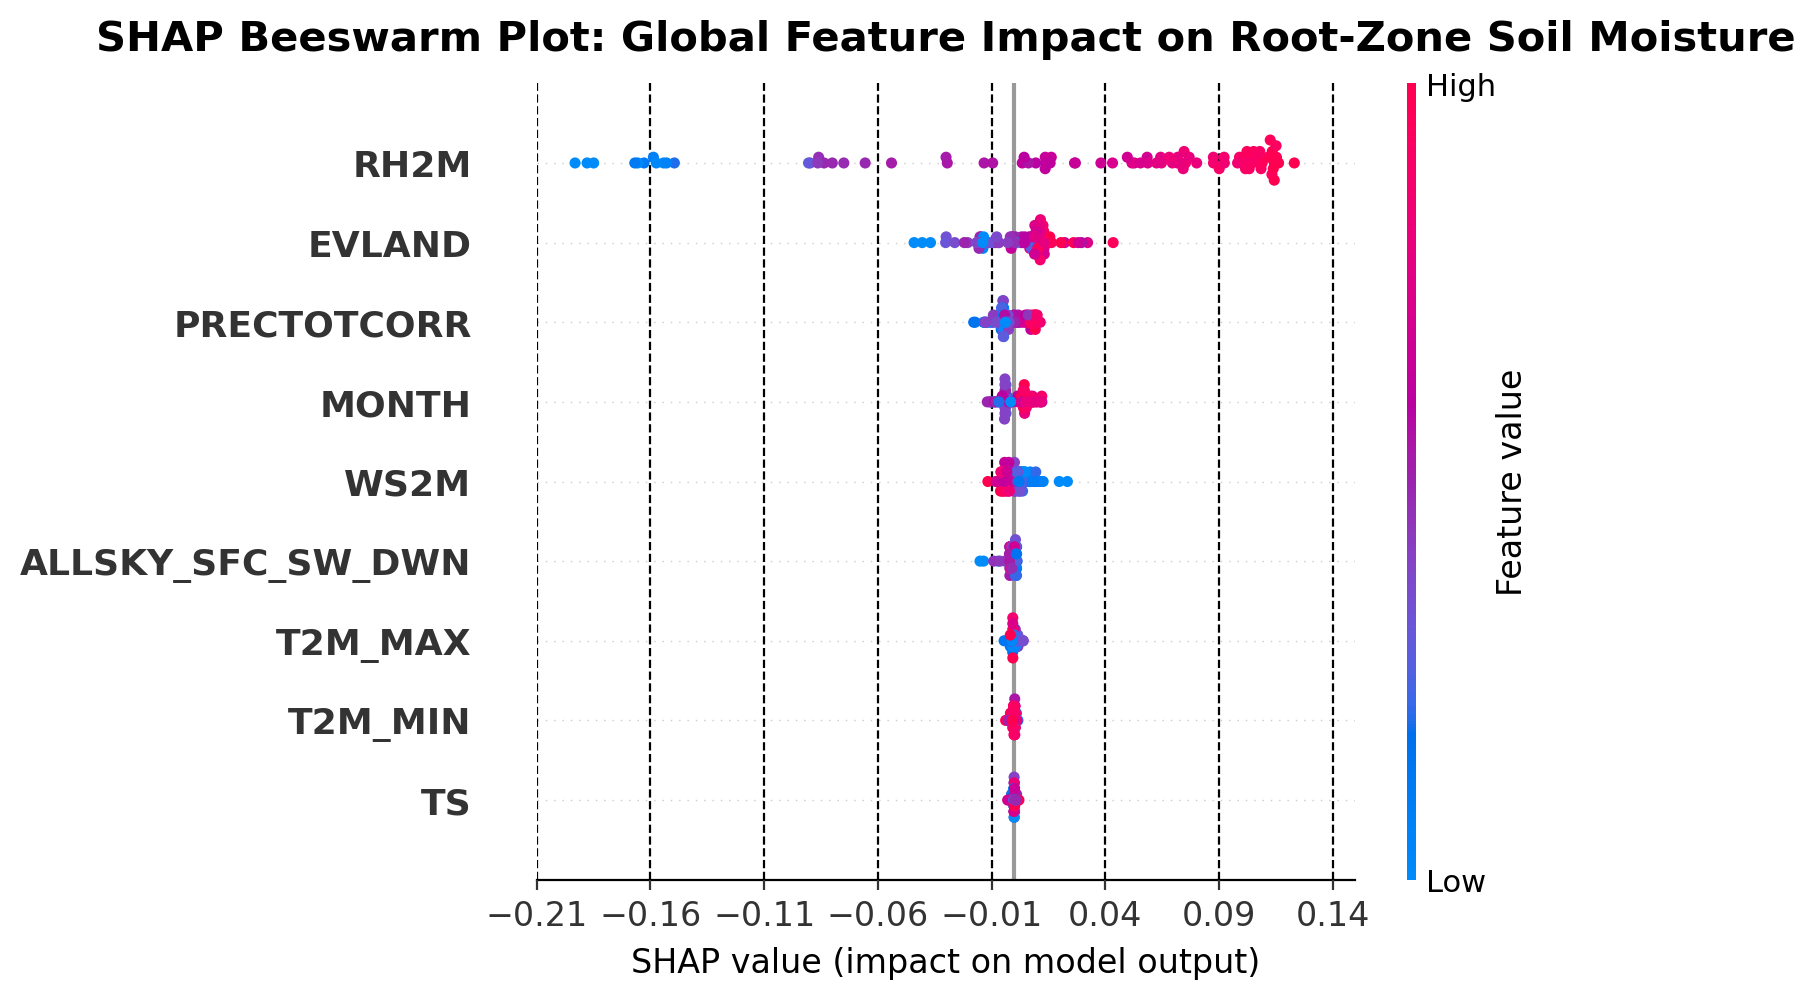

In [70]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
#Draw SHAP beeswarm plot
shap.plots.beeswarm(explanation, max_display=10, show=False)
x_min, x_max = -0.21, 0.15
plt.xlim(x_min, x_max)
plt.xticks(np.arange(x_min, x_max + 0.001, 0.05), fontsize=12)
plt.yticks(fontsize=13, fontweight='bold')
ax.set_axisbelow(False)
plt.grid(True, axis='x', linestyle='--', alpha=1.0, color='#000000')
plt.title(
    "SHAP Beeswarm Plot: Global Feature Impact on Root-Zone Soil Moisture",
    fontsize=15,
    fontweight="bold",
    pad=12,
)
plt.xlabel("SHAP value (impact on model output)", fontsize=12, labelpad=5)
plt.tight_layout()
# plt.savefig("shap_beeswarm_plot.png", dpi=300, bbox_inches='tight')
plt.show()

#### <h2>Interpreting SHAP Beeswarm Plots: Root-Zone Soil Moisture Model</h2>

<h2>Overview of Model Predictions</h2>
In this Random Forest Regressor model predicting **Root-Zone Soil Wetness (`GWETROOT`)**, global feature importance is heavily dominated by atmospheric moisture indicators (`RH2M`) and land surface water fluxes (`EVLAND`), followed by direct mass input (`PRECTOTCORR`).

---

<h2>Detailed Feature Interpretation</h2>

`1.` **RH2M (Relative Humidity at 2 Meters) — Primary Positive Driver**
* **Visual Behavior:** `RH2M` has the widest horizontal SHAP value spread ($\approx -0.19$ to $+0.12$), indicating it is the single most influential feature in the model.
  * **Red dots (High RH):** Concentrated on the right side ($>0$), pushing predicted root-zone soil moisture higher.
  * **Blue dots (Low RH):** Stretched far to the left ($<0$), severely reducing predicted soil moisture.
* **Hydrological Explanation:** High relative humidity lowers atmospheric Vapor Pressure Deficit (VPD), dampening evaporative demand and enabling soil in the root zone ($0\text{–}1\text{ m}$) to retain moisture. Low RH creates dry atmospheric conditions that rapidly draw water out of the soil canopy.

`2.` **EVLAND (Evaporation Land) — Positive Relationship (Water-Limited Regime)**
* **Visual Behavior:** Red dots (high evaporation) align with positive SHAP values ($+0.01$ to $+0.04$), whereas blue dots (low evaporation) cluster on the negative side.
* **Hydrological Explanation:** In terrestrial hydrology, land evaporation is primarily *water-limited*. High land evaporation rates can only occur when sufficient root-zone soil moisture is available to supply water to the surface. Thus, high `EVLAND` serves as an active signature of a wet soil state.

`3.` **PRECTOTCORR (Corrected Total Precipitation) — Direct Positive Input**
* **Visual Behavior:** Blue dots sit on the negative side, while red dots sit on the positive side.
* **Hydrological Explanation:** Precipitation represents the direct mass inflow of water into the soil column. Higher precipitation increases the water volume infiltrating into the root zone.

`4.` **MONTH — Seasonal Modulation**
* **Visual Behavior:** Distinct grouping where different periods of the year shift predictions higher or lower.
* **Hydrological Explanation:** Captures cyclical wet/dry seasons inherent to the region’s climatology, accounting for temporal lag in deep soil moisture storage.

`5.` **WS2M (Wind Speed at 2 Meters) — Inverse (Negative) Relationship**
* **Visual Behavior:** Red dots (high wind speed) sit on the left ($<0$), while blue dots (low wind speed) sit on the right ($>0$).
* **Hydrological Explanation:** Higher surface wind speeds increase aerodynamic resistance dynamics, accelerating turbulent transport of water vapor away from the surface and canopy. This elevated drying effect depletes root-zone water content, yielding an inverse relationship with `GWETROOT`.

`6.` **Surface Energy Features (ALLSKY_SFC_SW_DWN, T2M_MAX, T2M_MIN, TS) — Minor Global Impact**
* **Visual Behavior:** Clustered tightly around a SHAP value of $0.00$ with minimal horizontal spread.
* **Hydrological Explanation:** While solar irradiance and surface temperatures dictate potential evapotranspiration, the Random Forest relies more heavily on humidity (`RH2M`) and actual flux (`EVLAND`) to resolve the exact moisture state of the root zone.

---

<h2>Report Summary Paragraph</h2>

> Model interpretability via SHAP beeswarm analysis reveals that **Relative Humidity at 2m (`RH2M`)** is the primary driver of predicted root-zone soil wetness (`GWETROOT`), exhibiting a strong positive relationship where low humidity penalties reach up to $-0.19$ in SHAP value. **Land Evaporation (`EVLAND`)** and **Precipitation (`PRECTOTCORR`)** also show strong positive impacts, reflecting the water-limited nature of terrestrial evapotranspiration where high surface evaporation signals abundant soil water availability. Conversely, **Wind Speed at 2m (`WS2M`)** exhibits an inverse relationship with soil wetness: elevated wind speeds shift SHAP values negatively due to enhanced aerodynamic drying of the surface layer. Surface temperature metrics (`TS`, `T2M_MAX`, `T2M_MIN`) and solar radiation (`ALLSKY_SFC_SW_DWN`) play secondary roles compared to direct atmospheric moisture and flux variables.

### SHAP Waterfall Plot

---
A SHAP waterfall plot explains a **single local prediction** by breaking down how each feature's contribution moves the model output from the baseline value to the final prediction.

---

``Key Visual Components``

* **Baseline Value $E[f(X)]$ (Bottom of Plot):** The expected (average) output value of the model across the entire dataset. This serves as the starting anchor. (e.g. $E[f(X)] = 0.845$: This is the **baseline**. If the model had to guess the root-zone soil moisture without knowing any of the specific weather conditions for this sample, it would guess $0.845$. This is the average prediction across the ``training dataset``.)
* **Final Prediction $f(x)$ (Top of Plot):** The model's actual predicted output for this specific individual instance.
* **Horizontal Bars & Direction:**
  * **Red / Pink Bars (Positive Impact):** Point right and increase the prediction relative to the baseline ($+\phi_i$).
  * **Blue Bars (Negative Impact):** Point left and decrease the prediction relative to the baseline ($-\phi_i$).
* **Bar Length:** Represents the magnitude of the feature's influence on this specific prediction. Longer bars indicate stronger effects.
* **Feature Names & Values (Y-axis):** Listed on the left alongside their actual raw numerical values for this sample.
* **SHAP Values ($\phi_i$):** Numbers displayed inside or directly next to the arrows showing the exact numerical shift added or subtracted by each feature.

---

``Step-by-Step Interpretation Guide``

`1.` **Locate the Baseline ($E[f(X)]$):** Start at the bottom axis value. This is what the model would predict on average without knowing specific feature values for this instance.

`2.` **Trace the Cumulative Shifts (Bottom to Top):** Move upward row by row. Each row shows how much a feature pushes the prediction higher (red) or lower (blue) from the running total.

`3.` **Identify the Dominant Drivers:** Features near the top of the waterfall generally have the largest contribution to pushing the prediction away from the mean.

`4.` **Verify the Additive Sum:** The sum of all individual SHAP values added to the baseline equals the final output:

$$f(x) = E[f(X)] + \sum_{i=1}^{M} \phi_i$$

---

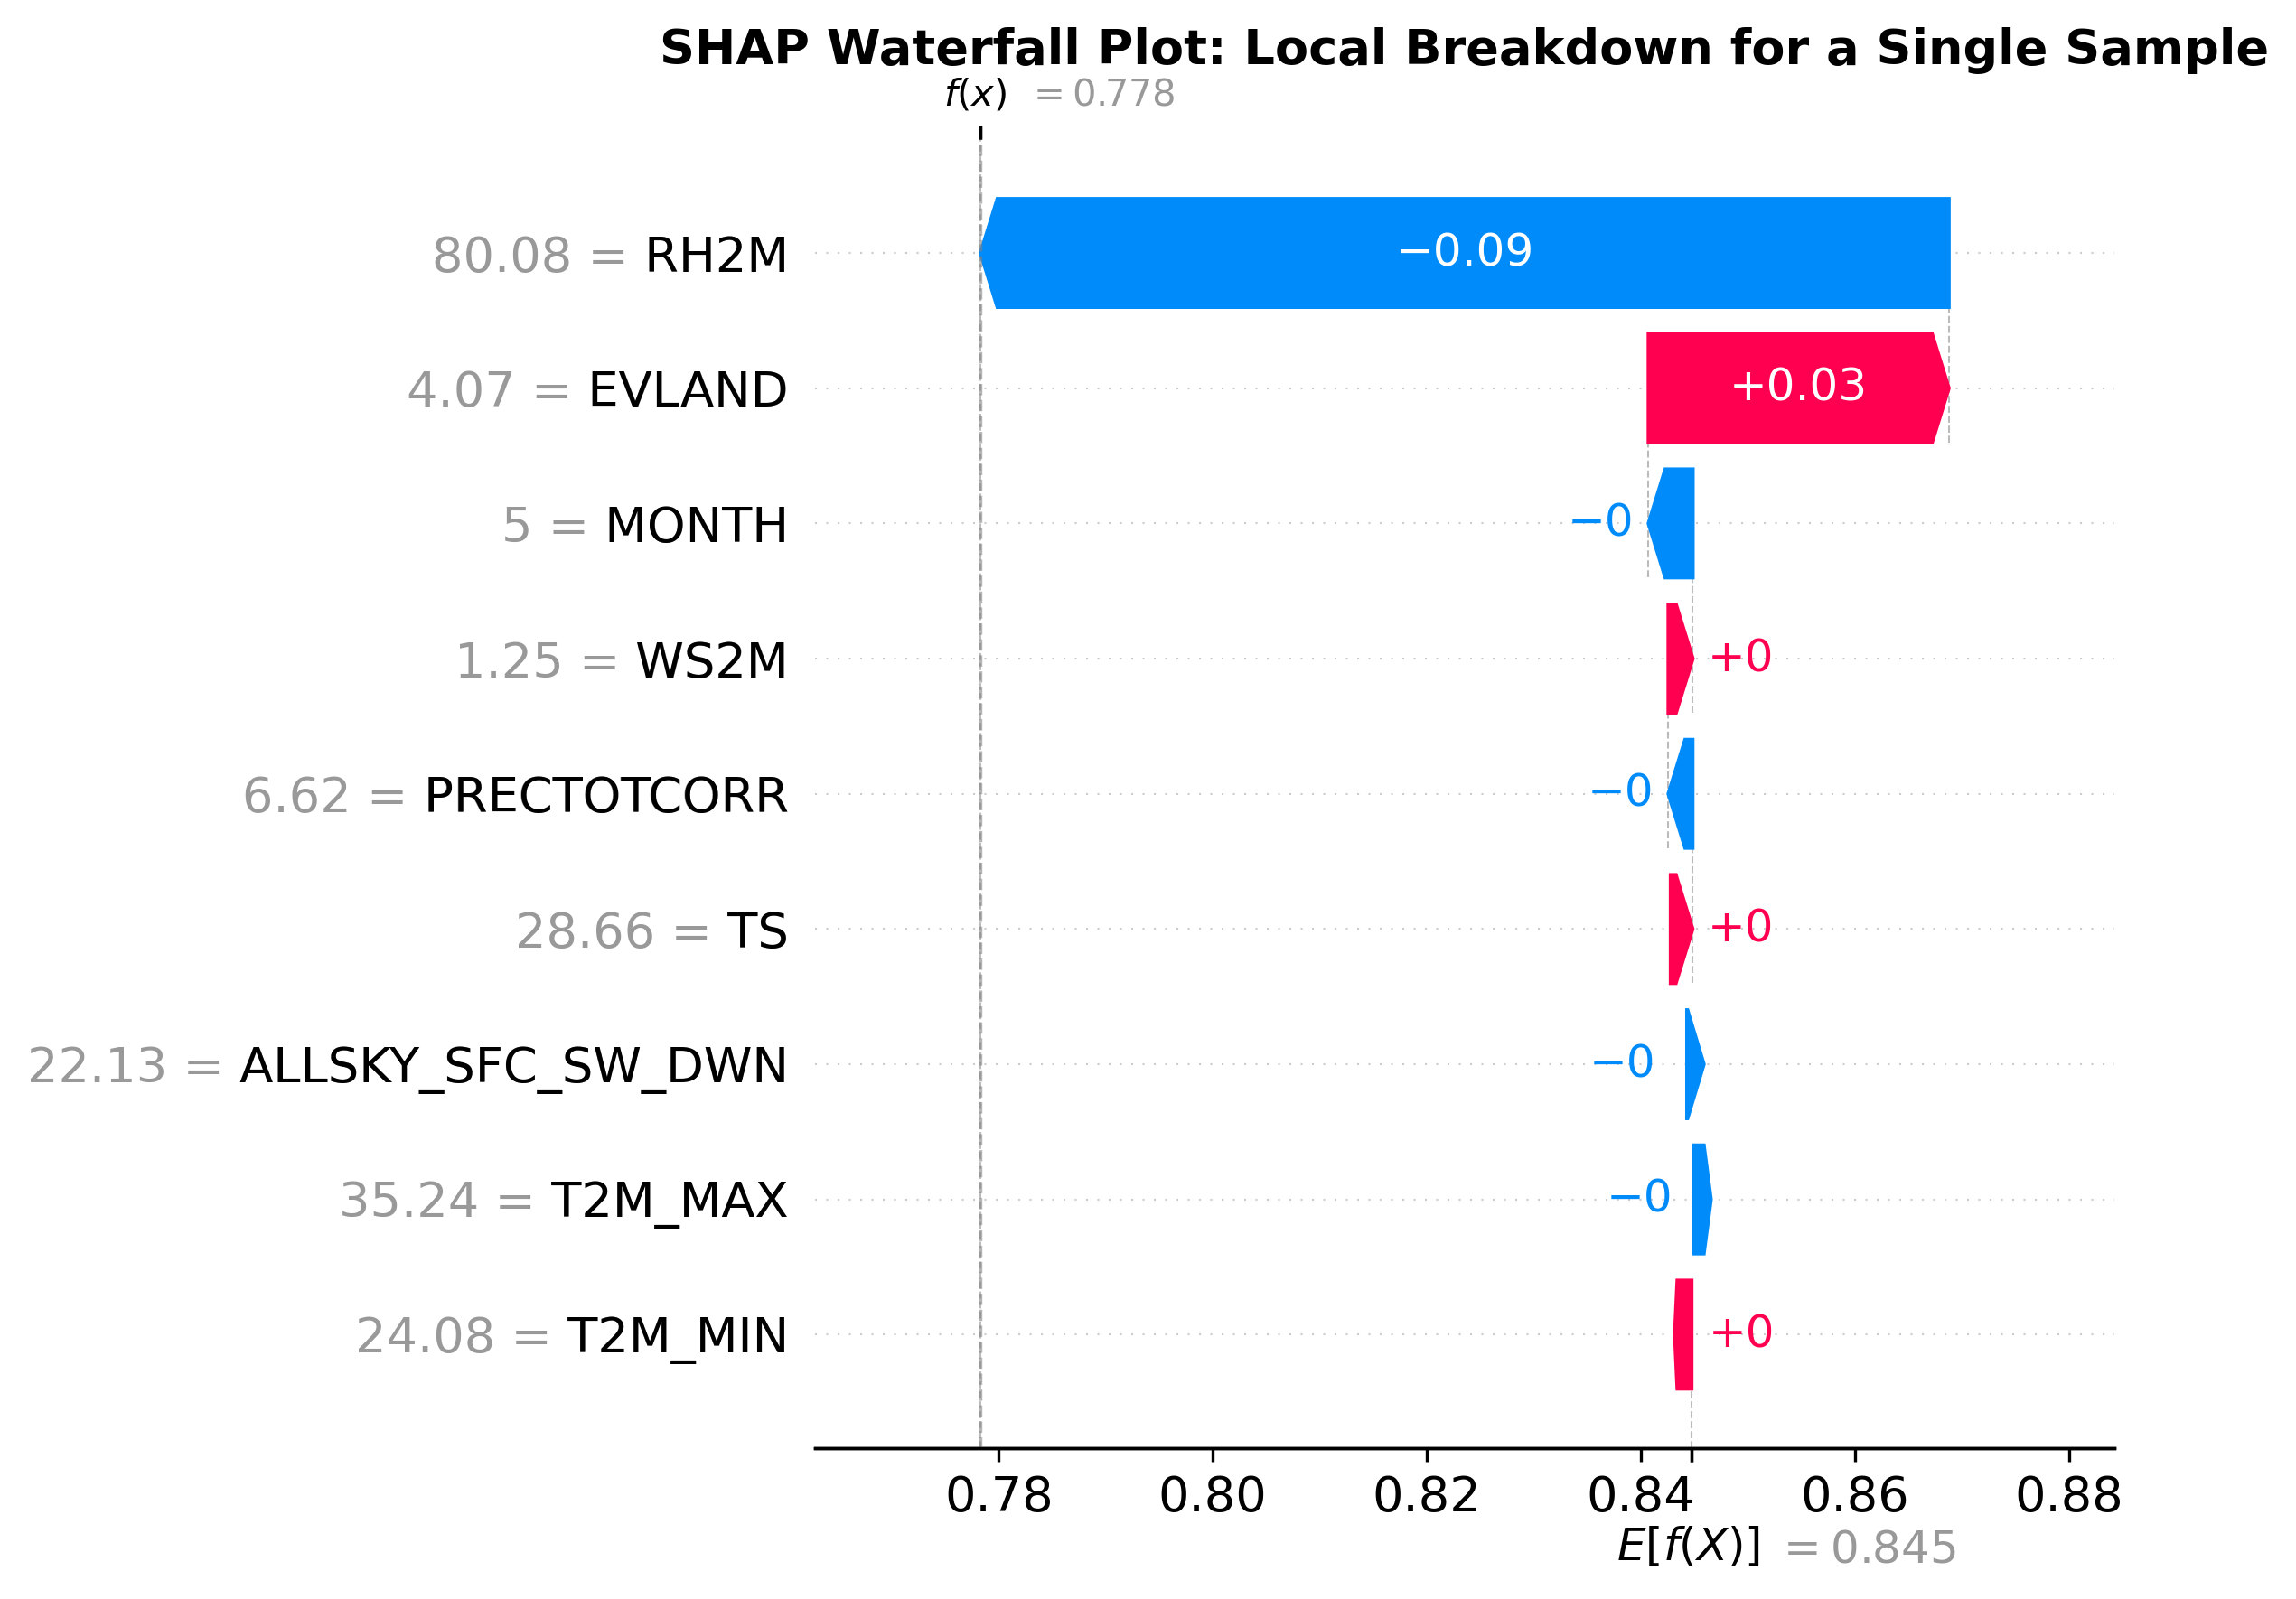

In [71]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

shap.plots.waterfall(explanation[0], show=False)

plt.gca().set_axisbelow(True)
plt.grid(True, axis="x", linestyle="--", alpha=0.35, color="gray")

plt.title(
    "SHAP Waterfall Plot: Local Breakdown for a Single Sample",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### SHAP Waterfall Plot: Single Sample (Local) Explanation

> **CRITICAL NOTE:** Unlike global plots (like the Beeswarm or Heatmap) that show overall trends across the entire dataset, the Waterfall Plot is strictly a **local explanation**. It explains the model's exact decision-making process for **one single row of data** (e.g., one specific day or location). It shows how the specific feature values of this one sample pushed the prediction away from the global average.

---

``Visual Breakdown for this Specific Instance``

`1.` **The Starting Point (Baseline: $E[f(X)] = 0.845$)**
* This is the foundation of the plot. If the model had to guess the root-zone soil moisture without knowing *any* of the specific weather conditions for this single sample, it would guess $0.845$. This represents the average prediction across the entire training dataset.

`2.` **Features with Minimal or No Impact**
* Notice that features like `T2M_MIN` ($24.08$), `WS2M` ($1.25$), and `MONTH` ($5$) have SHAP values of $-0$ or $+0$. 
* This means that for *this exact sample*, these specific values had almost zero influence. They did not significantly shift the model's prediction away from the global baseline.

`3.` **The Major Local Drivers (EVLAND & RH2M)**
* **`EVLAND = 4.07`:** The land evaporation for this sample actively increases the prediction. The red arrow points right, adding **$+0.03$** to the running total.
* **`RH2M = 80.08`:** This is the dominant factor for this specific sample. A relative humidity of $80.08$ drastically reduces the model's prediction here. The large blue arrow points left, dragging the prediction down by **$-0.09$**.

`4.` **The Final Local Output ($f(x) = 0.778$)**
* This is the model's final prediction for this **single sample**. 
* The waterfall perfectly bridges the gap between the global average and the local prediction. Following the math from the bottom up: 
  **$0.845$** (baseline) **$+ 0.03$** (`EVLAND`) **$- 0.09$** (`RH2M`) $\approx$ **$0.778$** (the final prediction, factoring in microscopic decimals from the zero-impact features).

### SHAP Heatmap



The SHAP heatmap visualizes the entire dataset's explanations at once, organizing samples to reveal macro-level patterns in how features drive the model's predictions.

``Key Visual Components``

* **X-axis (Instances):** Each vertical column represents a single sample from your dataset. SHAP automatically orders these instances by their final predicted value, from lowest on the left to highest on the right.
* **Top Line Graph ($f(x)$):** This black line shows the model's final prediction for each instance. It slopes upward from left to right because the underlying instances are sorted by this exact output.
* **Y-axis (Features):** Features are ranked top-to-bottom by their overall global importance. The solid black bars on the far right show the mean absolute SHAP value for each feature (essentially a built-in summary bar plot).
* **Color Scale:**
  * **Red (Positive):** The feature *increased* the model's prediction for that specific instance.
  * **Blue (Negative):** The feature *decreased* the model's prediction for that specific instance.
  * **White (Neutral):** The feature had zero or near-zero impact on the prediction.

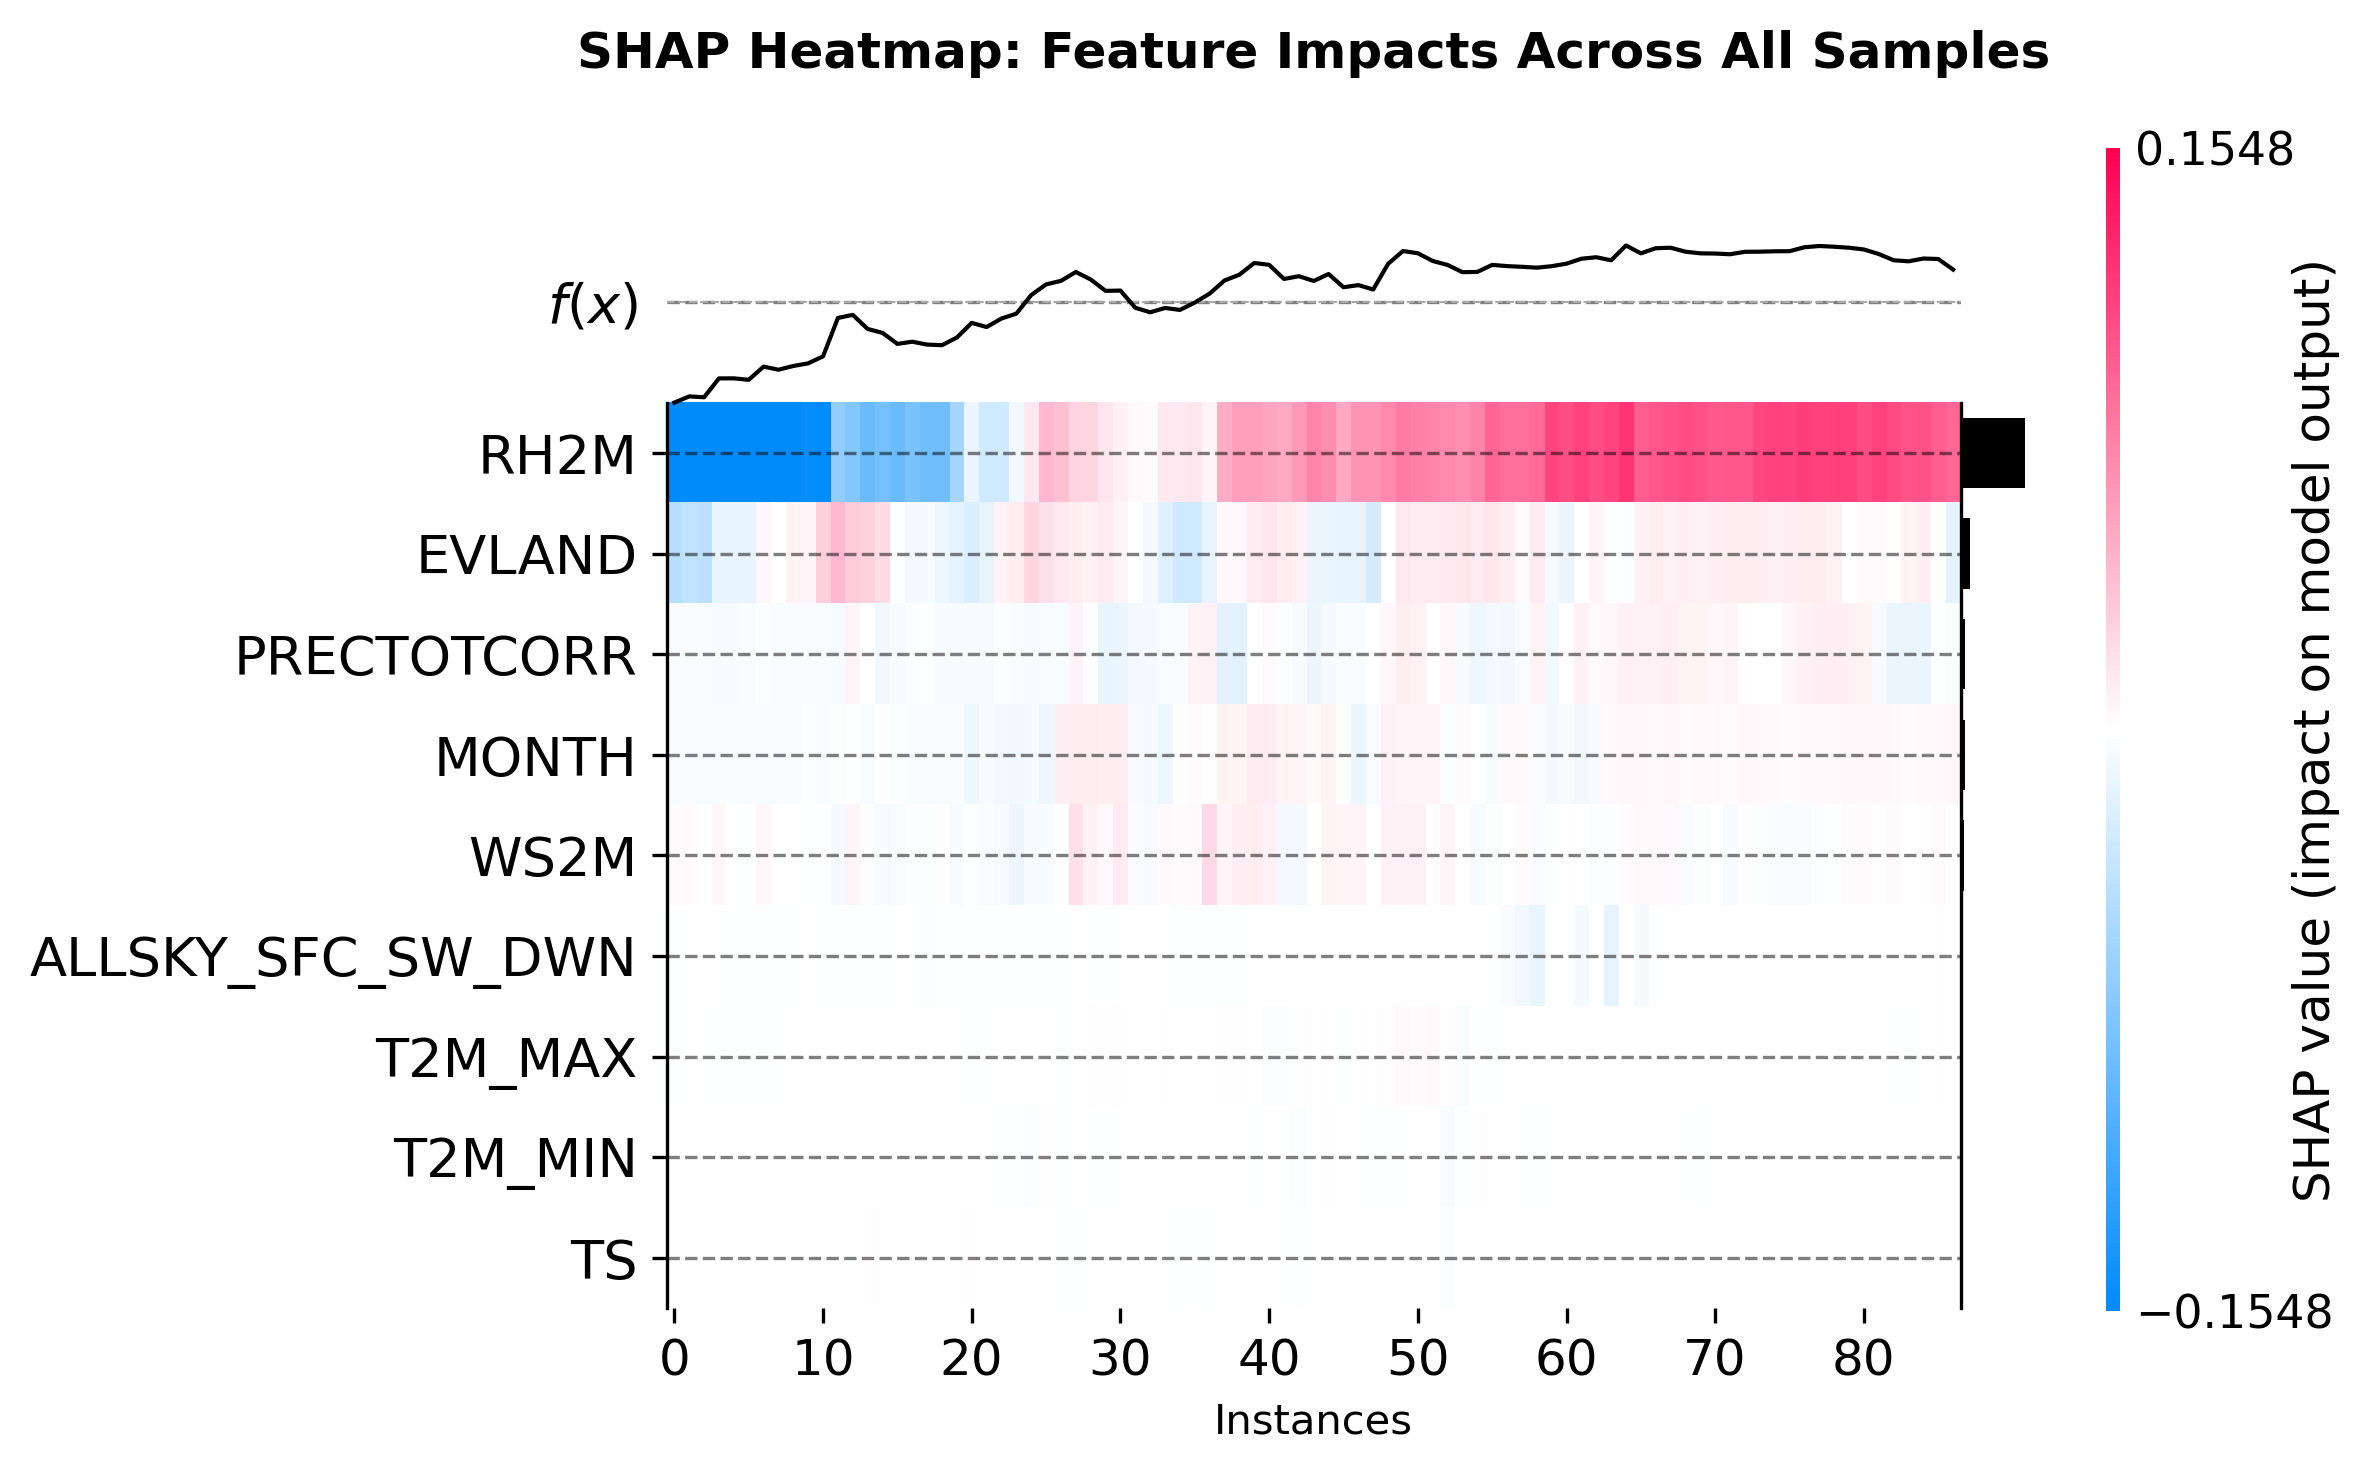

In [99]:
plt.figure(figsize=(12, 6), dpi=300)

# Plot heatmap for the whole dataset (or a subset like explanation[:1000])
# shap.plots.heatmap(explanation, show=False)
shap.plots.heatmap(explanation[:1000], show=False)  # Optional: Limit to first 1000 samples for clarity
plt.gca().set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.5, color='#000000')
plt.xticks(np.arange(0, 90, 10), fontsize=12)
plt.title("SHAP Heatmap: Feature Impacts Across All Samples", pad=20, fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretation: Insights from Your Specific Model

`1.` **RH2M Completely Dominates**
The top row (`RH2M`) is the strongest signal in the plot. For the lowest predictions (instances $0$ to $20$ on the far left), `RH2M` is deep blue, meaning it actively dragged the predictions down. For the highest predictions (instances $40$ to $80$ on the right), it is solid red, meaning it is the primary engine pushing the predictions higher.

`2.` **Most Features Have Near-Zero Impact**
Features from `PRECTOTCORR` down to `TS` are almost entirely white across the entire dataset. This visually confirms what the black marginal bars on the right indicate: these variables barely shift the model's predictions at all compared to relative humidity.

`3.` **EVLAND's Secondary, Patchy Role**
`EVLAND` shows localized clusters of impact rather than a uniform gradient. For example, around instances $10$ to $15$, `EVLAND` shows a distinct pink/red patch. This means for that specific small subset of samples, evaporation actually helped slightly boost the prediction, fighting against the heavy negative downward pull (blue) of `RH2M` for those same samples.

---
**The Heatmap is specifically designed to reveal if different "types" of days or locations rely on different features.**

* Beeswarm Plot: EVLAND had some positive impact.

* Heatmap: We can clearly see that EVLAND only mattered for a small cluster of samples right around instances 10–15 (the pink patch).

### SHAP Dependence Plots

``How to Read a SHAP Dependence Plot``

A SHAP dependence plot is the best way to see exactly how a single feature affects your model's predictions across your entire dataset. It acts like a traditional scatter plot, but with the added superpower of revealing hidden **interactions** between variables.

Here is a clear, step-by-step breakdown of how to interpret it:

``1. The X-Axis (Feature Value)``
* This is the actual, real-world numerical value of the feature you are analyzing (e.g., your Relative Humidity percentage).
* You read it from left to right, going from the lowest recorded values in your dataset to the highest.

``2. The Y-Axis (SHAP Value / Model Impact)``
* This represents how much that specific feature value **changed the model's prediction** away from the baseline average.
* **Above the 0.0 line (Positive):** This specific value pushed the model's prediction *higher*.
* **Below the 0.0 line (Negative):** This specific value dragged the model's prediction *lower*.
* **Exactly on the 0.0 line:** This specific value had absolutely zero impact on the model's output.

``3. The Shape (The Main Trend)``
* Look at the overall shape of the dot cluster to understand the core rule the model learned.
* **Linear:** A straight diagonal line means the feature scales evenly (e.g., more rain always equals more soil moisture).
* **Non-linear / Tipping Points:** A flat line that suddenly spikes or drops indicates a threshold. For example, if the dots suddenly shoot upward after 84% humidity, the model learned that humidity only matters after it crosses that specific saturation point.

``4. The Color Scale (Feature Interactions)``
* SHAP automatically colors the dots using a **second feature** to show how two variables work together.
* Look at the vertical spread of the dots at any single point on the X-axis. If dots at the exact same humidity level are scattered vertically, it is because of that second color-coded feature!
* **How to decode it:** If the dots sitting higher up on the Y-axis are pink/red (high evaporation) and the dots sitting lower down are blue (low evaporation), it tells you exactly how evaporation combined with humidity to change the model's prediction for those specific samples.

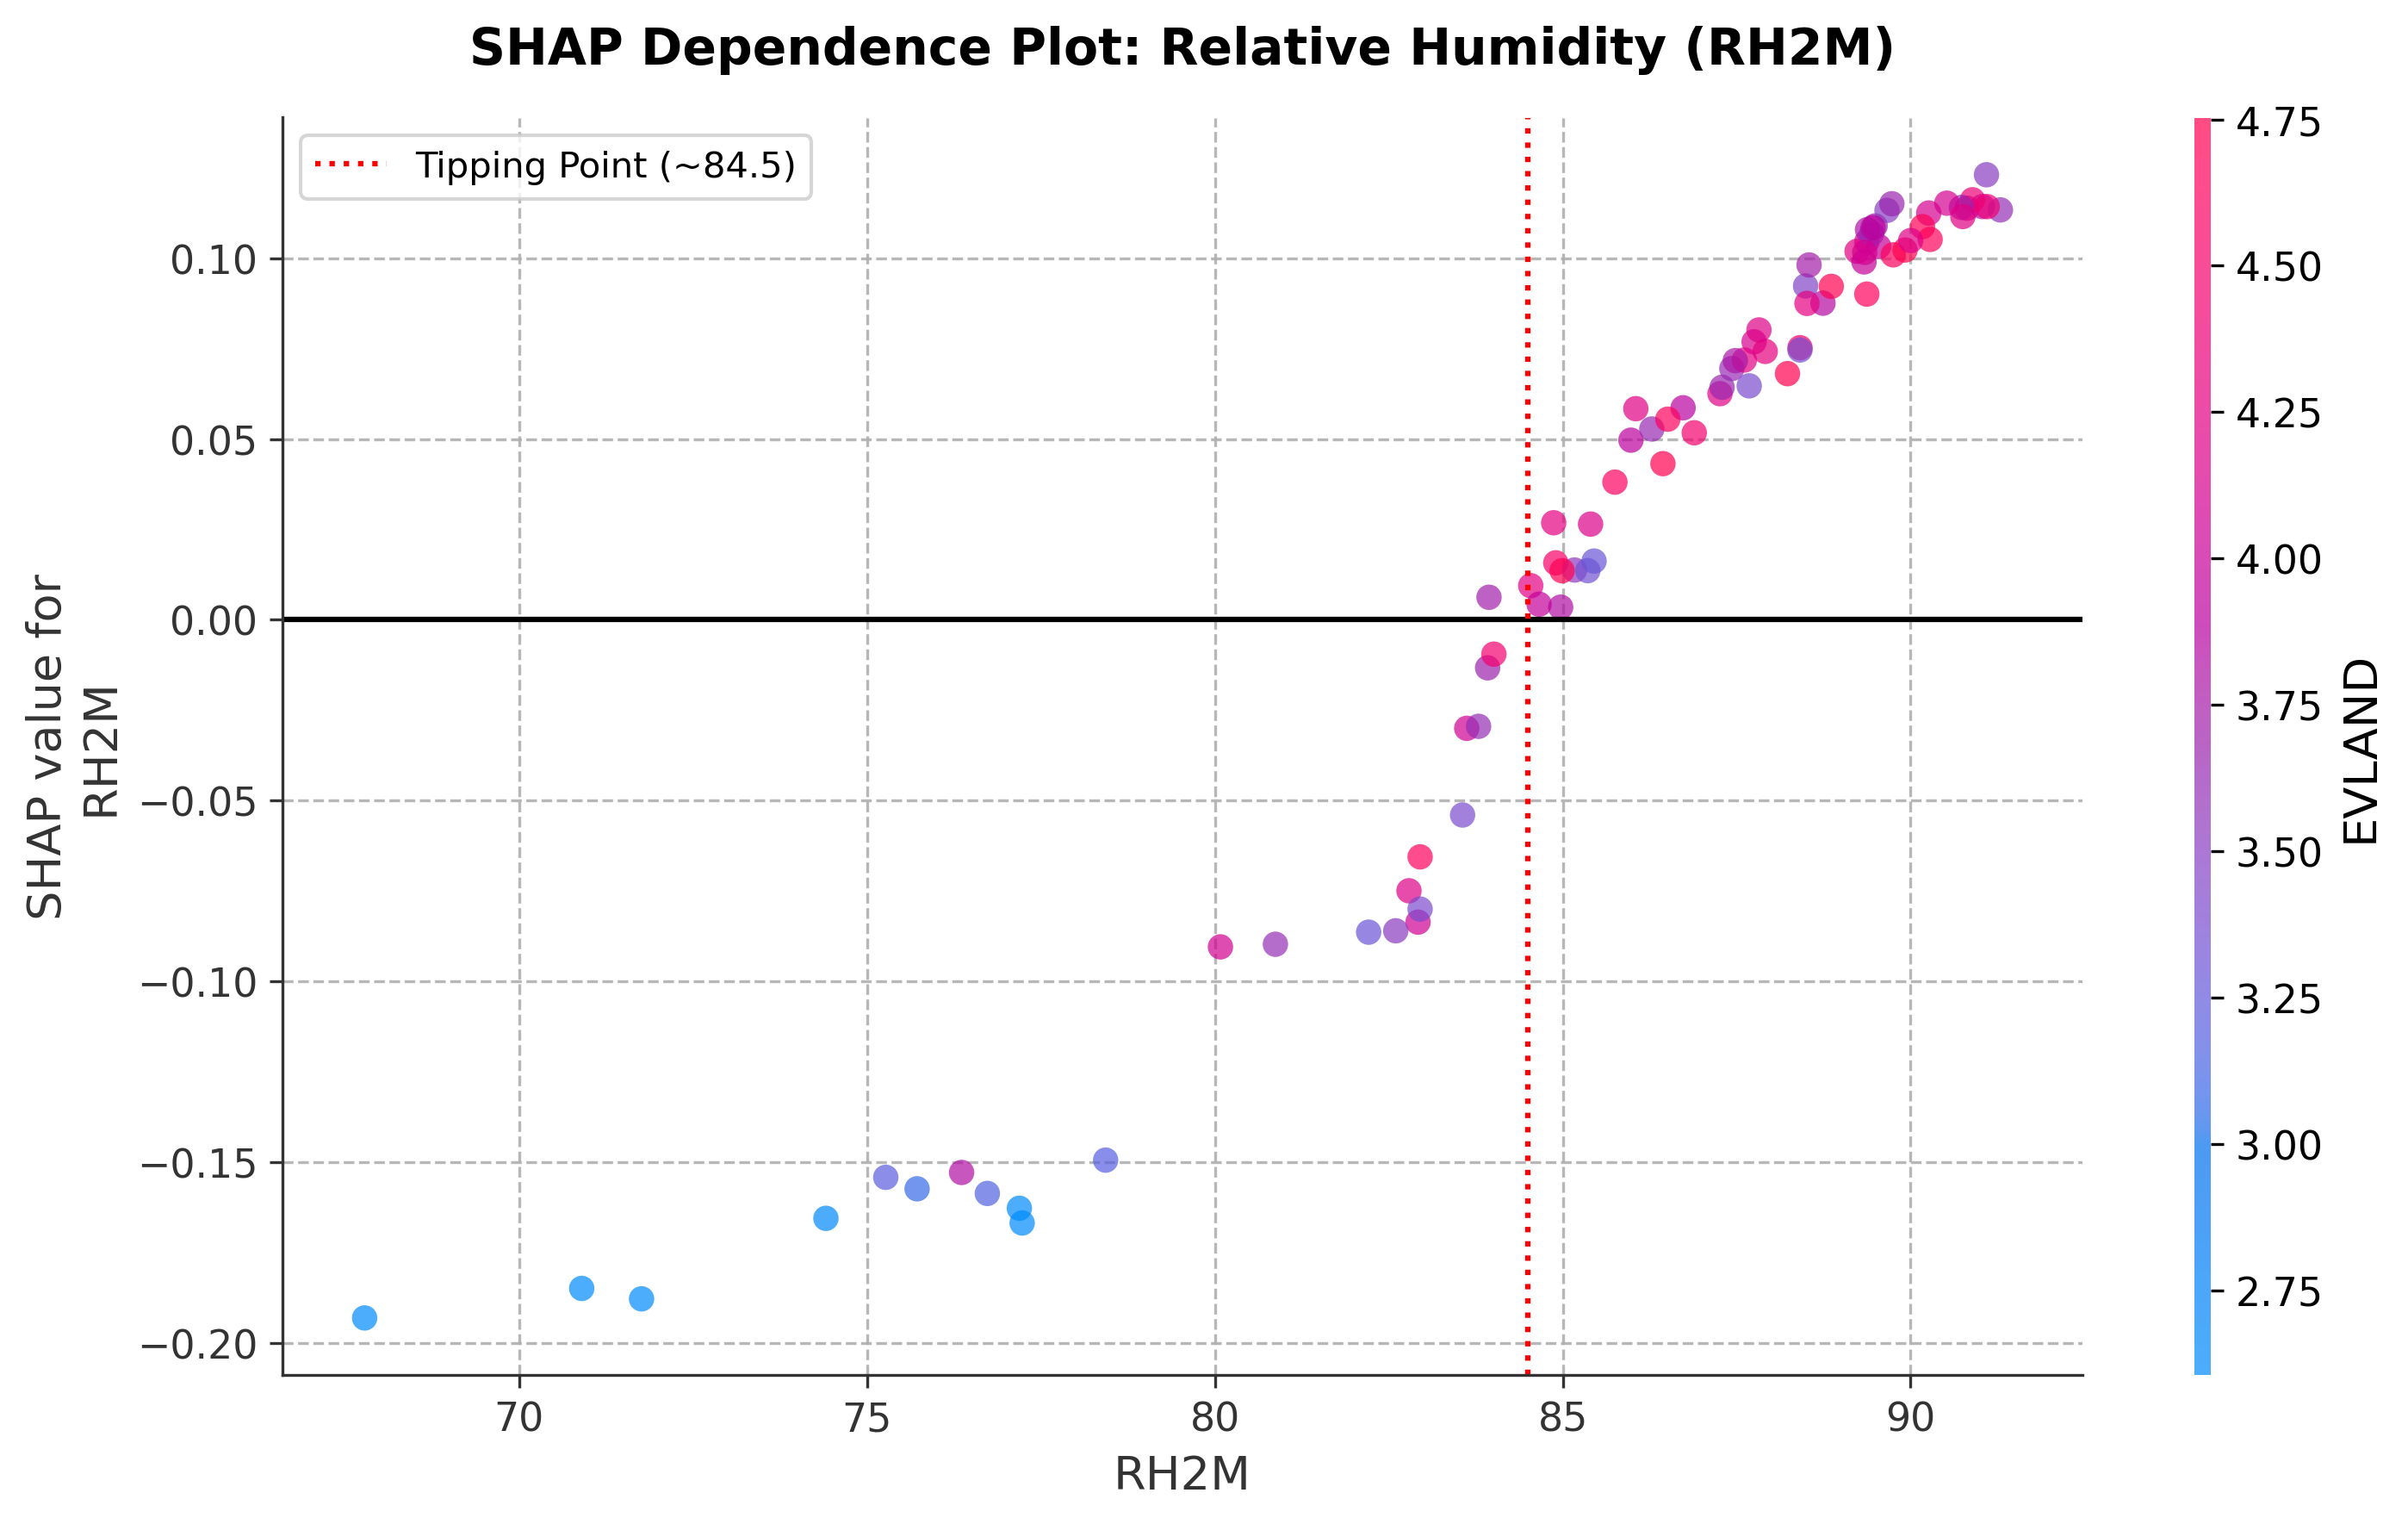

In [115]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
shap.dependence_plot(
    "RH2M",
    shap_values_array,
    X_test,
    display_features=X_test,
    ax=ax,
    dot_size=50,
    alpha=0.7,
    show=False
)

# --- ADDING THE REFERENCE LINES ---
# 1. Horizontal baseline at SHAP = 0.0 (Neutral Impact)
ax.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=1)

# 2. Vertical line at the tipping point (RH2M = 84.5)
ax.axvline(84.5, color='red', linewidth=1.5, linestyle=':', zorder=1, label="Tipping Point (~84.5)")
ax.legend(loc="upper left", frameon=True)
# ----------------------------------

plt.title(
    "SHAP Dependence Plot: Relative Humidity (RH2M)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)
plt.grid(True, axis='both', linestyle='--', alpha=0.9, zorder=0)
ax.set_axisbelow(True) 
plt.tight_layout()
plt.show()

#### Interpretation: RH2M Interaction with Land Evaporation

``1. The Non-Linear Main Effect (The S-Curve)``
With the clearer visualization, you can see that the relationship is not just a straight diagonal line; it forms an "S" shape.
* **Dry conditions (`RH2M < 80`):** The SHAP values flatten out near the bottom left (around $-0.15$ to $-0.20$). The model heavily penalizes the soil moisture prediction, but getting *even drier* than $75$ doesn't change the penalty much.
* **The Steep Climb (`RH2M 82` to `86`):** This is the critical transition zone. A tiny increase in humidity within this narrow window causes a massive upward jump in the model's prediction.
* **Saturated conditions (`RH2M > 88`):** The curve begins to flatten out again near the top right. Once humidity is already very high, adding a few more percentage points has diminishing returns on the prediction. Once the air is already extremely saturated (e.g., 90% humidity), the root-zone is likely already highly protected from evaporation or sitting at maximum capacity. Pushing the humidity even higher to 92% doesn't drastically alter the physical reality on the ground anymore. The environment is just "maxed out

``2. Interaction with Land Evaporation (`EVLAND`)``
* The added transparency reveals that the dots are densely packed into a single, tight line with virtually no vertical scatter.
* Because there is no vertical spread at specific `RH2M` values, it confirms that `EVLAND` (the color) **does not fundamentally change** how `RH2M` affects the prediction. 
* The color gradient simply shows a strong environmental correlation in our test data set: low humidity days (bottom left) also happen to be low evaporation days (blue), while high humidity days (top right) consistently align with high evaporation days (pink/red).